# Merging Climate Datasets Exercise

Work through this notebook to practice harmonizing and merging two climate datasets that differ in temporal cadence and spatial resolution.

You will: 
- Load two public NOAA datasets directly from the cloud
- Subset to the continental US (use 230°E–300°E in longitude since the data span 0–360°)
- Use `xr.resample` to aggregate time and `xr.interp` to match grids
- Combine the variables with `xr.merge` for joint analysis

Refer back to the answer key after attempting each step.


## 1. Setup


In [ ]:
import matplotlib.pyplot as plt
import xarray as xr

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ImportError:
    ccrs = None
    cfeature = None

TEMP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/ncep.reanalysis/surface/air.sig995.2020.nc"
PRECIP_URL = "https://psl.noaa.gov/thredds/dodsC/Datasets/cpc_global_precip/precip.2020.nc"

LAT_RANGE = (20, 50)  # degrees North
LON_RANGE_360 = (230, 300)  # degrees East (equivalent to -130° to -60°)
LON_RANGE_180 = (-130, -60)  # convenience if a dataset uses -180° to 180°

TIME_RANGE = slice("2020-06-01", "2020-06-30")

## 2. Load the datasets

Open both remote datasets with `xr.open_dataset`, passing a reasonable chunk size for the time dimension. Assign the resulting objects to `air` and `precip`.


In [2]:
# TODO: load the air temperature and precipitation datasets.
# Example: air = xr.open_dataset(..., chunks={"time": 8})

air = xr.open_dataset(TEMP_URL, chunks={"time": 8})
precip = xr.open_dataset(PRECIP_URL, chunks={"time": 8})
# raise NotImplementedError("Assign datasets to `air` and `precip`.")

## 3. Subset to the continental United States and June 2020

Select the bounding box provided above and limit the time range to June 2020 for both datasets. Store the results in `air_us` and `precip_us`.
Remember that longitude runs from 0° to 360°, so select 230°E–300°E. Check whether each coordinate is ascending or descending before building the slice.


In [ ]:
# TODO: subset both datasets using `sel`, handling coordinate ordering as
# needed.
air_us = air.sel(
    lat=slice(
        51, 23), lon=slice(
            230, 300), time=slice(
                "2020-06-01", "2020-06-30"))
precip_us = precip.sel(
    lat=slice(
        51, 23), lon=slice(
            230, 300), time=slice(
                "2020-06-01", "2020-06-30"))
# raise NotImplementedError("Create `air_us` and `precip_us`.")

## 4. Align temporal cadence

Aggregate the six-hourly air temperatures to daily means with `xr.resample`. Name the resulting DataArray `air_daily`.


In [ ]:
# TODO: use xr.resample to create daily means.
air_daily = air_us.resample(time="1D").mean()

# Convert from Kelvin to Celsius
air_daily = air_daily - 273.15


# raise NotImplementedError("Create `air_daily`.")

In [5]:
print(air_daily)

<xarray.Dataset> Size: 39kB
Dimensions:  (lat: 11, lon: 29, time: 30)
Coordinates:
  * lat      (lat) float32 44B 50.0 47.5 45.0 42.5 40.0 ... 32.5 30.0 27.5 25.0
  * lon      (lon) float32 116B 230.0 232.5 235.0 237.5 ... 295.0 297.5 300.0
  * time     (time) datetime64[ns] 240B 2020-06-01 2020-06-02 ... 2020-06-30
Data variables:
    air      (time, lat, lon) float32 38kB dask.array<chunksize=(1, 11, 29), meta=np.ndarray>
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2017/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    References:                      http://www.psl.noaa.gov/data/gridded/dat...
    DODS_EXTRA.Unlimited_Dimension:  t

## 5. Interpolate to the precipitation grid

Use `xr.interp` to interpolate the daily air temperatures onto the precipitation grid (`precip_us.lat` and `precip_us.lon`). Store the interpolated result in `air_interp`.


In [ ]:
# TODO: interpolate the resampled temperature field onto the precipitation
# grid.
air_interp = air_daily.interp(lat=precip_us.lat, lon=precip_us.lon)
# raise NotImplementedError("Create `air_interp`.")

## 6. Merge the datasets

Convert the aligned arrays into datasets with clear variable names and merge them with `xr.merge`. Save the output as `merged`.


In [ ]:
# TODO: build datasets and merge them into one object named `merged`.
merged_precip_temp = xr.merge([air_interp, precip_us])
# raise NotImplementedError("Create `merged`.")

## 7. Inspect your result

Once your pipeline runs without `NotImplementedError`, evaluate the following cell to sanity-check the merged dataset.


In [ ]:
# The assertions below should pass once you have completed the exercise.
# assert set(merged.data_vars) == {"air_temperature", "daily_precip"}
# assert merged.air_temperature.dims == merged.daily_precip.dims
print(merged_precip_temp)

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 30, lat: 56, lon: 140)
Coordinates:
  * time     (time) datetime64[ns] 240B 2020-06-01 2020-06-02 ... 2020-06-30
  * lat      (lat) float32 224B 50.75 50.25 49.75 49.25 ... 24.25 23.75 23.25
  * lon      (lon) float32 560B 230.2 230.8 231.2 231.8 ... 298.8 299.2 299.8
Data variables:
    air      (time, lat, lon) float32 941kB dask.array<chunksize=(1, 56, 140), meta=np.ndarray>
    precip   (time, lat, lon) float32 941kB dask.array<chunksize=(8, 56, 140), meta=np.ndarray>
Attributes:
    Conventions:                     COARDS
    title:                           4x daily NMC reanalysis (2014)
    history:                         created 2017/12 by Hoop (netCDF2.3)
    description:                     Data is from NMC initialized reanalysis\...
    platform:                        Model
    dataset_title:                   NCEP-NCAR Reanalysis 1
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    References:        

## 8. Check In

- Render both variables at the first timestep on a `cartopy` map to verify alignment visually (PlateCarree works well).
- Build a scatter plot comparing colocated temperature and precipitation values across the merged domain.
- Save the merged output with `to_netcdf` for future analysis.


## Slice to First Timestep

In [9]:
merged_time_1 = merged_precip_temp.isel(time=0)

## Plot on cartopy

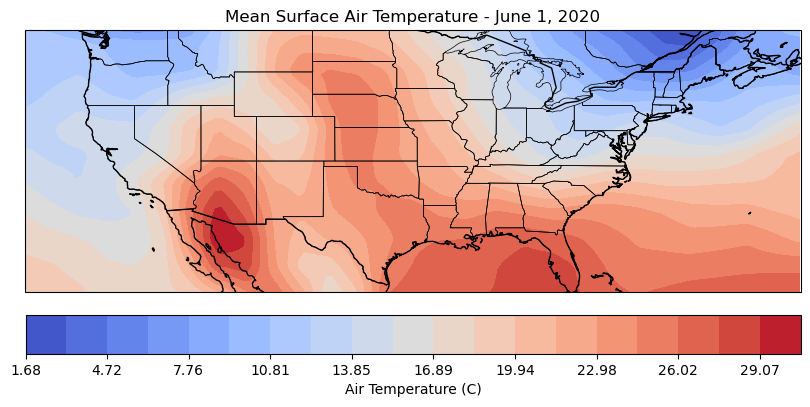

In [ ]:
# Worked with Copilot on the plotting section below.
import numpy as np

# Extract the DataArray from the Dataset
# replace `dataset` with your actual variable name
data = merged_time_1["air"].squeeze()

# Check for valid data
if data.size == 0 or np.isnan(data).all():
    raise ValueError("No valid data found in the selected variable.")

# Create contour levels
levels = np.linspace(np.nanmin(data), np.nanmax(data), 20)

# Create the plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linewidth=0.5)
# match your dataset bounds
ax.set_extent([230.2, 299.8, 25.25, 48.75], crs=ccrs.PlateCarree())

# Plot the data
contour = ax.contourf(
    data.lon, data.lat, data,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    levels=levels
)

# Add colorbar and title
plt.colorbar(
    contour,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    label="Air Temperature (C)")
plt.title("Mean Surface Air Temperature - June 1, 2020")

plt.show()

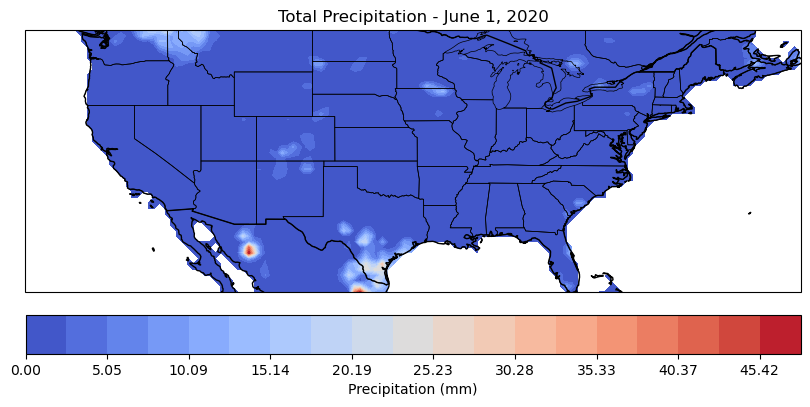

In [ ]:
# Extract the DataArray from the Dataset
# replace `dataset` with your actual variable name
data = merged_time_1["precip"].squeeze()

# Check for valid data
if data.size == 0 or np.isnan(data).all():
    raise ValueError("No valid data found in the selected variable.")

# Create contour levels
levels = np.linspace(np.nanmin(data), np.nanmax(data), 20)

# Create the plot
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linewidth=0.5)
# match your dataset bounds
ax.set_extent([230.2, 299.8, 25.25, 48.75], crs=ccrs.PlateCarree())

# Plot the data
contour = ax.contourf(
    data.lon, data.lat, data,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    levels=levels
)

# Add colorbar and title
plt.colorbar(
    contour,
    ax=ax,
    orientation="horizontal",
    pad=0.05,
    label="Precipitation (mm)")
plt.title("Total Precipitation - June 1, 2020")

plt.show()

## Create scatterplot of temperature and precip over the entire dataset and time period

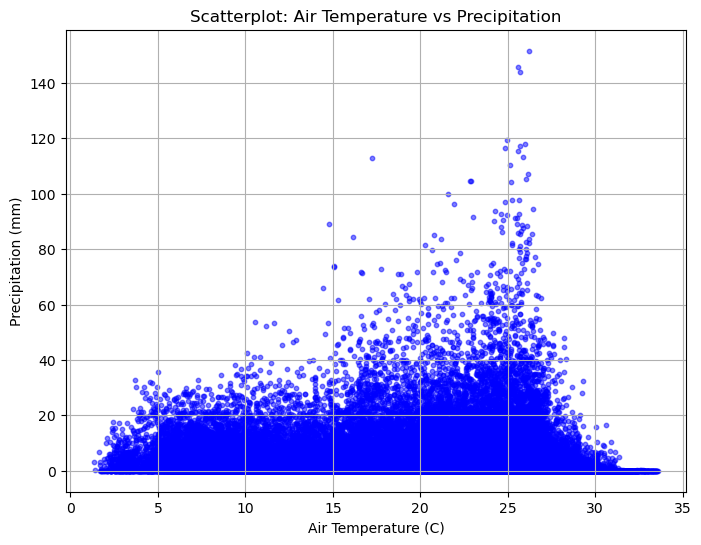

In [ ]:
# Asked copilot for a general example of a scatterplot from xarray and
# modified from there.
air_plot = merged_precip_temp["air"].values.flatten()
precip_plot = merged_precip_temp["precip"].values.flatten()

# Mask out NaNs
mask = ~np.isnan(air_plot) & ~np.isnan(precip_plot)
air_clean = air_plot[mask]
precip_clean = precip_plot[mask]

# Create scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(air_clean, precip_clean, alpha=0.5, s=10, c="blue")
plt.xlabel("Air Temperature (C)")
plt.ylabel("Precipitation (mm)")
plt.title("Scatterplot: Air Temperature vs Precipitation")
plt.grid(True)
plt.show()

## Save File to NetCDF

In [ ]:
clean_ds = xr.Dataset(
    {
        "air": (["time", "lat", "lon"], merged_precip_temp["air"].data),
        "precip": (["time", "lat", "lon"], merged_precip_temp["precip"].data)
    },
    coords={
        "time": merged_precip_temp["time"],
        "lat": merged_precip_temp["lat"],
        "lon": merged_precip_temp["lon"]
    }
)
clean_ds.to_netcdf(
    "module_3_checkin_jared_katz.nc",
    mode="w",
    format="NETCDF4")

In [ ]:
clean_ds.to_netcdf(
    "module_3_checkin_jared_katz.nc",
    mode="w",
    format="NETCDF4")